# Phase 1: Data Cleaning, Feature Engineering & EDA

Run each cell in order. Plots display inline below the EDA cells.

Open from project root: `Project 1 NCPL`

## 1. Imports & configuration

In [3]:
%matplotlib inline

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "Data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "Data" / "Telco_customer_churn.xlsx"
OUTPUT_DIR = PROJECT_ROOT / "output" / "phase1"
FIGURES_DIR = OUTPUT_DIR / "figures"
CLEANED_CSV = OUTPUT_DIR / "cleaned_telco_churn.csv"
SHEET_NAME = "Telco_Churn"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Washim\Desktop\Project 1 NCPL


## 2. Load raw data

In [4]:
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print(f"Loaded {len(df_raw):,} rows x {len(df_raw.columns)} columns")
df_raw.head()

Loaded 7,043 rows x 33 columns


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 3. Clean data

In [5]:
df = df_raw.copy()

df = df.drop(columns=[c for c in ["Count", "Lat Long"] if c in df.columns])

dup_rows = df.duplicated().sum()
dup_ids = df["CustomerID"].duplicated().sum()
df = df.drop_duplicates()
if dup_ids:
    df = df.drop_duplicates(subset="CustomerID", keep="first")
print(f"Removed {dup_rows} duplicate rows, {dup_ids} duplicate CustomerIDs")

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
mask = df["Total Charges"].isna() & (df["Tenure Months"] == 0)
df.loc[mask, "Total Charges"] = df.loc[mask, "Monthly Charges"]
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

df["Churn Reason"] = df["Churn Reason"].fillna("Not Applicable")

obj_cols = df.select_dtypes(include=["object", "str"]).columns
for col in obj_cols:
    df[col] = df[col].astype(str).str.strip()

print("Missing values:", df.isna().sum().sum())
df.shape

Removed 0 duplicate rows, 0 duplicate CustomerIDs
Missing values: 0


(7043, 31)

## 4. Encode categorical variables

In [6]:
yes_no_cols = ["Gender", "Senior Citizen", "Partner", "Dependents", "Phone Service", "Paperless Billing"]
ternary_cols = ["Multiple Lines", "Online Security", "Online Backup", "Device Protection",
                "Tech Support", "Streaming TV", "Streaming Movies"]

binary_map = {"Yes": 1, "No": 0, "Male": 1, "Female": 0}
for col in yes_no_cols:
    df[f"{col}_encoded"] = df[col].map(binary_map)

ternary_map = {"Yes": 1, "No": 0, "No phone service": 0, "No internet service": 0}
for col in ternary_cols:
    df[f"{col}_encoded"] = df[col].map(ternary_map)

df["Contract_encoded"] = df["Contract"].map({"Month-to-month": 0, "One year": 1, "Two year": 2})
df["Internet Service_encoded"] = df["Internet Service"].map({"No": 0, "DSL": 1, "Fiber optic": 2})
df["Payment Method_encoded"] = df["Payment Method"].map({
    "Electronic check": 0, "Mailed check": 1, "Bank transfer (automatic)": 2, "Credit card (automatic)": 3
})
df["Churn_encoded"] = (df["Churn Label"] == "Yes").astype(int)

print("Encoded columns added.")
[c for c in df.columns if c.endswith("_encoded")]

Encoded columns added.


['Gender_encoded',
 'Senior Citizen_encoded',
 'Partner_encoded',
 'Dependents_encoded',
 'Phone Service_encoded',
 'Paperless Billing_encoded',
 'Multiple Lines_encoded',
 'Online Security_encoded',
 'Online Backup_encoded',
 'Device Protection_encoded',
 'Tech Support_encoded',
 'Streaming TV_encoded',
 'Streaming Movies_encoded',
 'Contract_encoded',
 'Internet Service_encoded',
 'Payment Method_encoded',
 'Churn_encoded']

## 5. Feature engineering

In [7]:
df["Tenure Group"] = pd.cut(
    df["Tenure Months"], bins=[0, 12, 24, 48, np.inf],
    labels=["0-12 months", "13-24 months", "25-48 months", "49+ months"], right=True
)
df["Avg Monthly Usage"] = df["Total Charges"] / df["Tenure Months"].replace(0, np.nan)
df["Avg Monthly Usage"] = df["Avg Monthly Usage"].fillna(df["Monthly Charges"])

service_cols = [c for c in df.columns if c.endswith("_encoded") and any(
    s in c for s in ["Online Security", "Online Backup", "Device Protection",
                     "Tech Support", "Streaming TV", "Streaming Movies"])]
df["Service Count"] = df[service_cols].sum(axis=1)

def payment_risk(row):
    if row["Contract"] == "Month-to-month" and row["Payment Method"] == "Electronic check" and row["Paperless Billing"] == "Yes":
        return "High"
    if row["Contract"] == "Month-to-month":
        return "Medium"
    return "Low"

df["Payment Risk"] = df.apply(payment_risk, axis=1)
df["Risk Segment"] = pd.cut(df["Churn Score"], bins=[0, 33, 66, 100],
                              labels=["Low Risk", "Medium Risk", "High Risk"], include_lowest=True)

print(f"Final shape: {df.shape}")
df[["Tenure Group", "Payment Risk", "Service Count", "Churn Label"]].head()

Final shape: (7043, 53)


,Tenure Group,Payment Risk,Service Count,Churn Label
0,0-12 months,Medium,2,Yes
1,0-12 months,High,0,Yes
2,0-12 months,High,3,Yes
3,25-48 months,High,4,Yes
4,49+ months,Medium,4,Yes


## 6. EDA — Churn distribution

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn rate: 26.54%


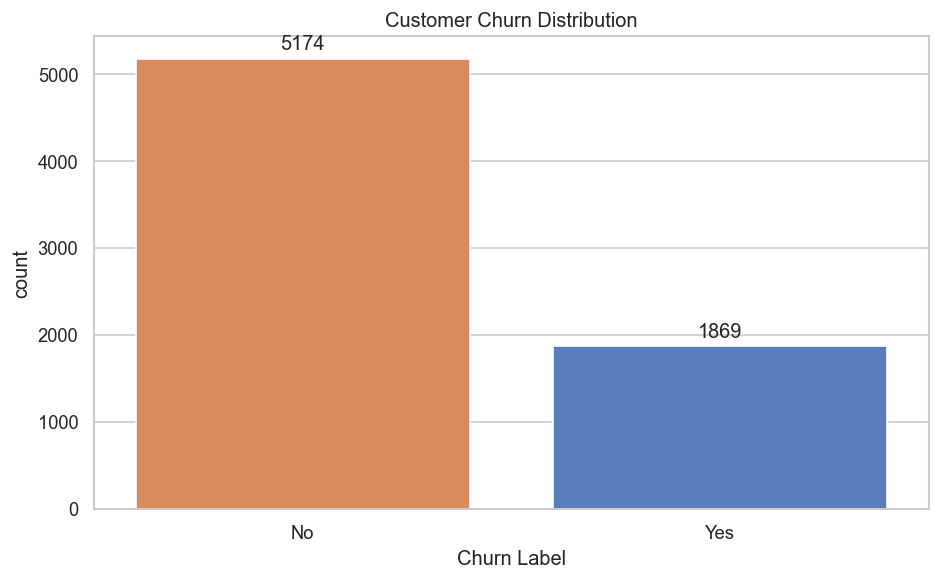

In [8]:
print(df["Churn Label"].value_counts())
print(f"Churn rate: {df['Churn_encoded'].mean():.2%}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="Churn Label", hue="Churn Label", order=["No", "Yes"], ax=ax, legend=False)
ax.set_title("Customer Churn Distribution")
for c in ax.containers:
    ax.bar_label(c, padding=3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_churn_distribution.png")
plt.show()

## 7. EDA — Churn rate by segment

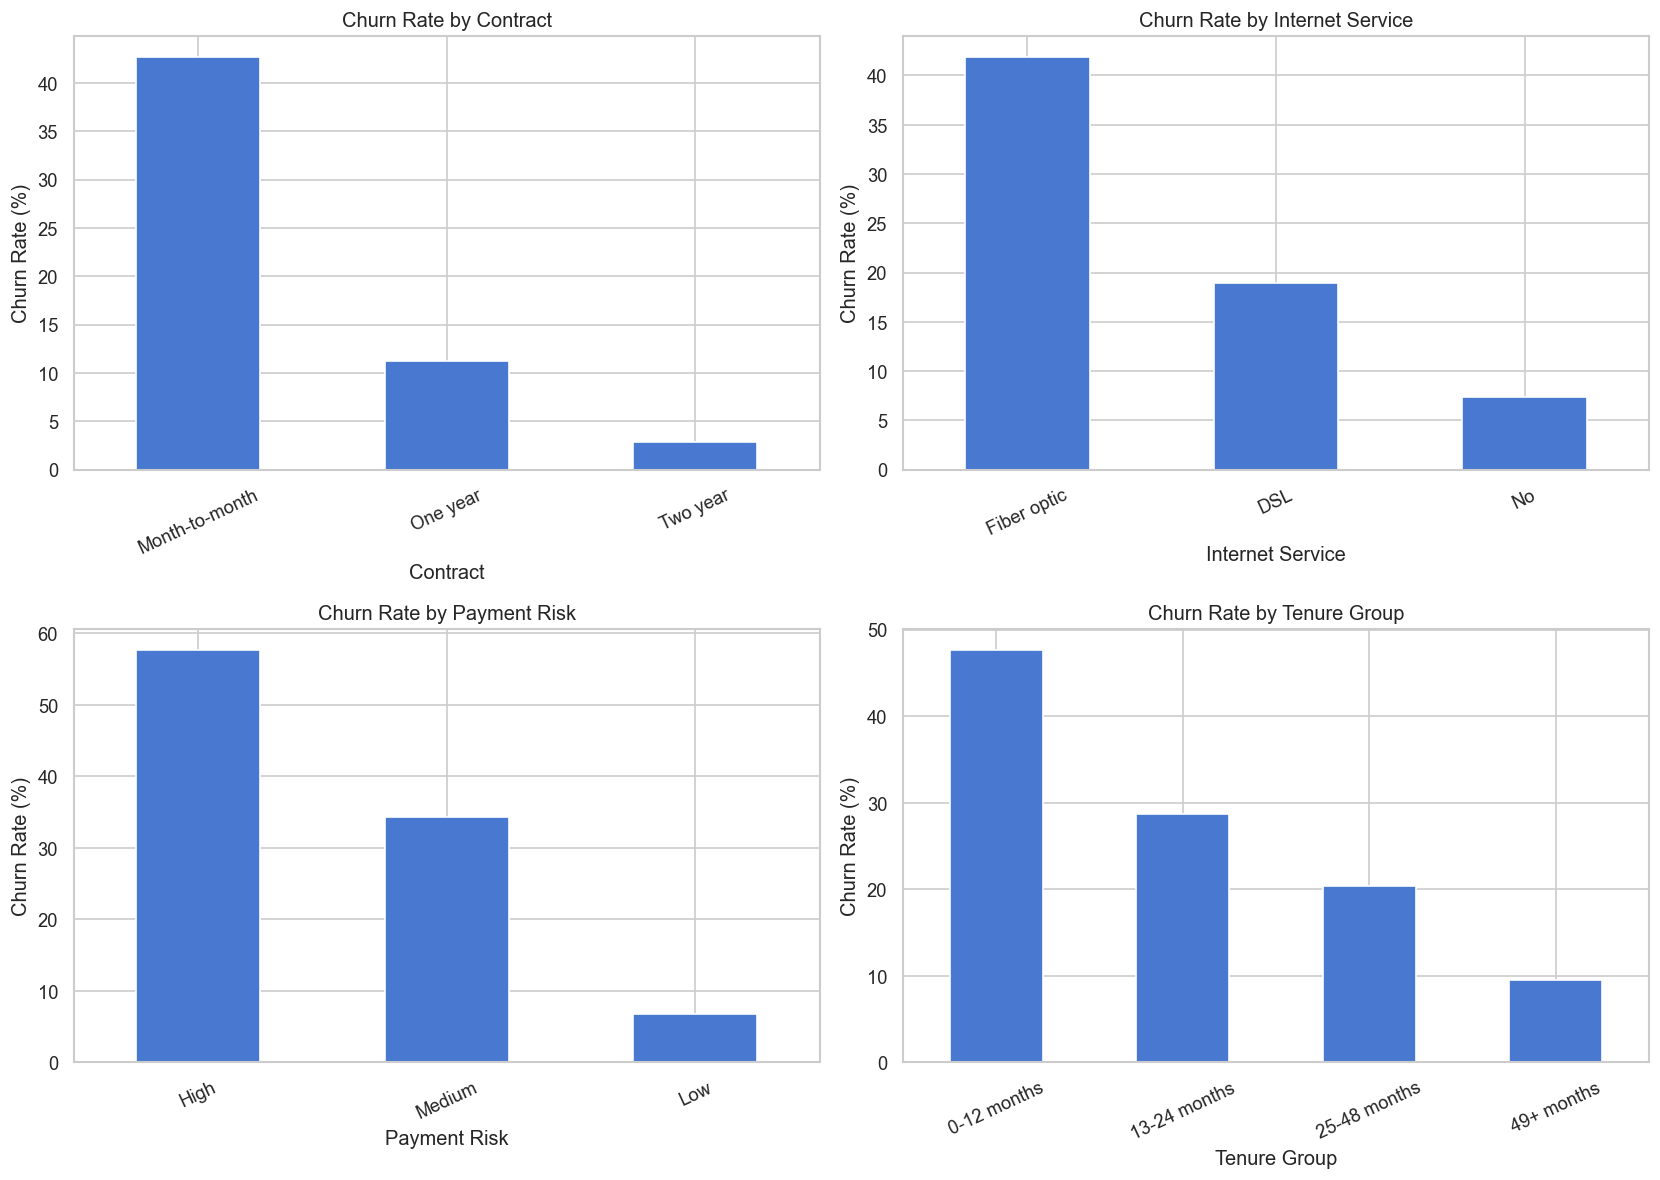

In [9]:
segment_cols = ["Contract", "Internet Service", "Payment Risk", "Tenure Group"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, segment_cols):
    pct = df.groupby(col, observed=True)["Churn_encoded"].mean().sort_values(ascending=False) * 100
    pct.plot(kind="bar", ax=ax)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_churn_by_segment.png")
plt.show()

## 8. EDA — Correlation heatmap

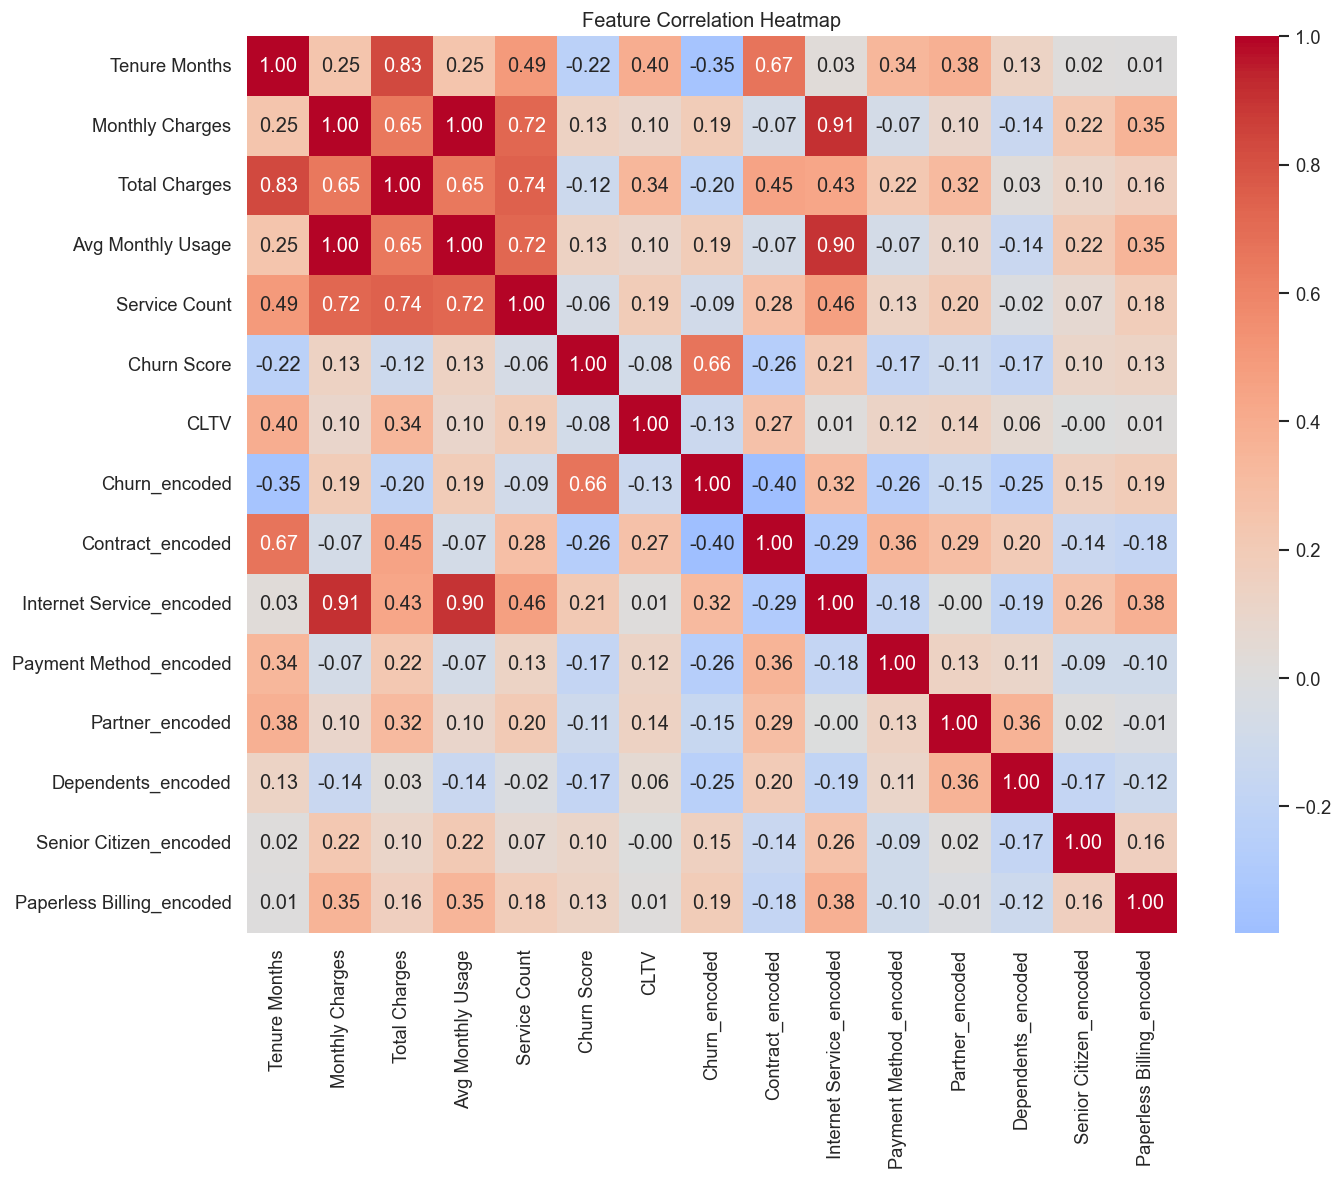

In [10]:
corr_cols = [
    "Tenure Months", "Monthly Charges", "Total Charges", "Avg Monthly Usage",
    "Service Count", "Churn Score", "CLTV", "Churn_encoded",
    "Contract_encoded", "Internet Service_encoded", "Payment Method_encoded",
    "Partner_encoded", "Dependents_encoded", "Senior Citizen_encoded", "Paperless Billing_encoded",
]
corr_cols = [c for c in corr_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_correlation_heatmap.png")
plt.show()

## 9. EDA — Feature importance (correlation with churn)

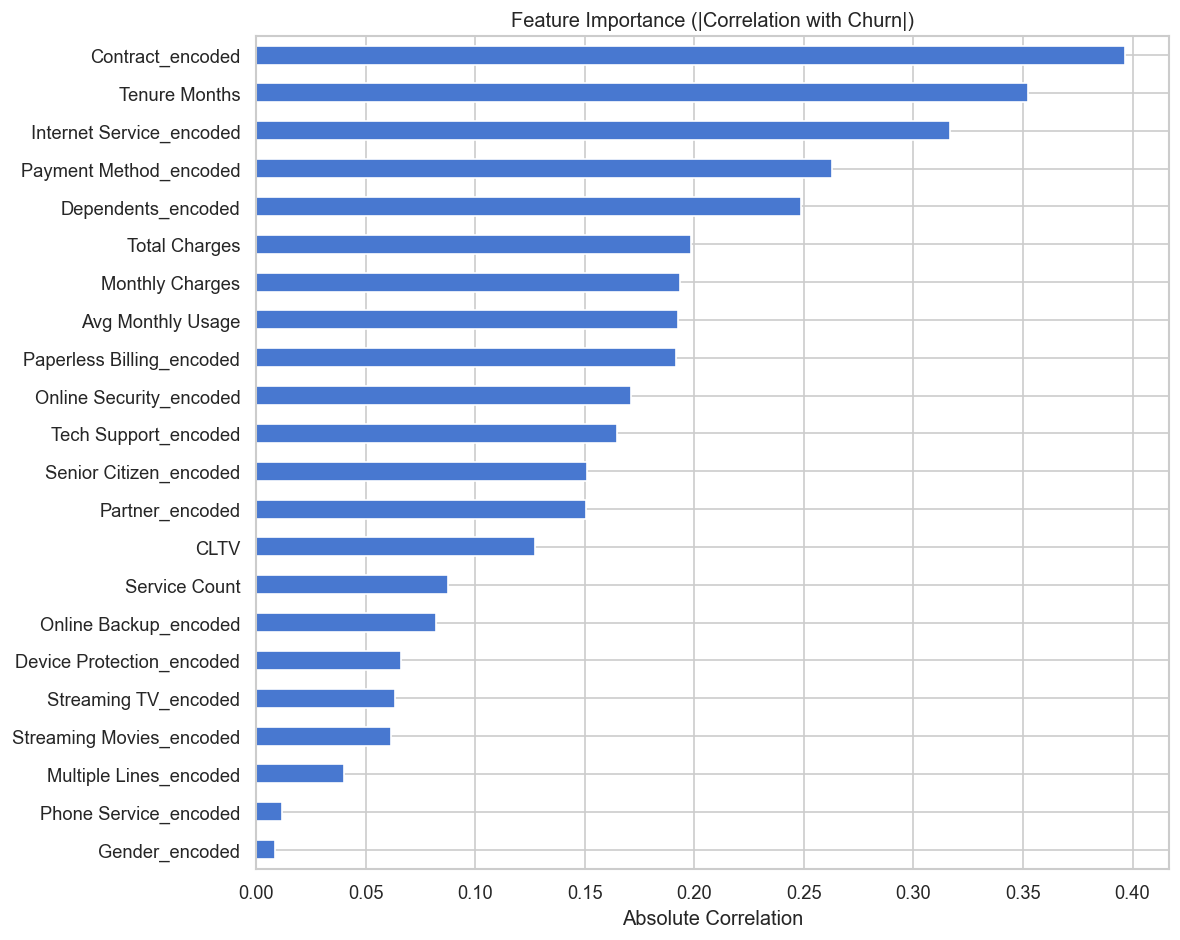

Contract_encoded             0.396713
Tenure Months                0.352229
Internet Service_encoded     0.316846
Payment Method_encoded       0.262818
Dependents_encoded           0.248542
Total Charges                0.198347
Monthly Charges              0.193356
Avg Monthly Usage            0.192531
Paperless Billing_encoded    0.191825
Online Security_encoded      0.171226
Name: Churn_encoded, dtype: float64

In [11]:
importance_cols = [
    "Tenure Months", "Monthly Charges", "Total Charges", "Avg Monthly Usage", "Service Count", "CLTV",
    "Contract_encoded", "Internet Service_encoded", "Payment Method_encoded",
    "Partner_encoded", "Dependents_encoded", "Senior Citizen_encoded", "Paperless Billing_encoded",
    "Phone Service_encoded", "Multiple Lines_encoded", "Online Security_encoded", "Online Backup_encoded",
    "Device Protection_encoded", "Tech Support_encoded", "Streaming TV_encoded", "Streaming Movies_encoded", "Gender_encoded",
]
importance_cols = [c for c in importance_cols if c in df.columns]
importance = df[importance_cols + ["Churn_encoded"]].corr(numeric_only=True)["Churn_encoded"].drop("Churn_encoded").abs().sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind="barh", ax=ax)
ax.set_title("Feature Importance (|Correlation with Churn|)")
ax.set_xlabel("Absolute Correlation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_feature_importance.png")
plt.show()
importance.sort_values(ascending=False).head(10)

## 10. EDA — Payment risk segmentation

,count,mean,churn_rate_pct
Payment Risk,,,
High,1397,0.576951,57.7
Low,3168,0.067551,6.8
Medium,2478,0.342615,34.3


C:\Users\Washim\AppData\Local\Temp\ipykernel_14568\1280077194.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk.reset_index(), x="Payment Risk", y="churn_rate_pct",


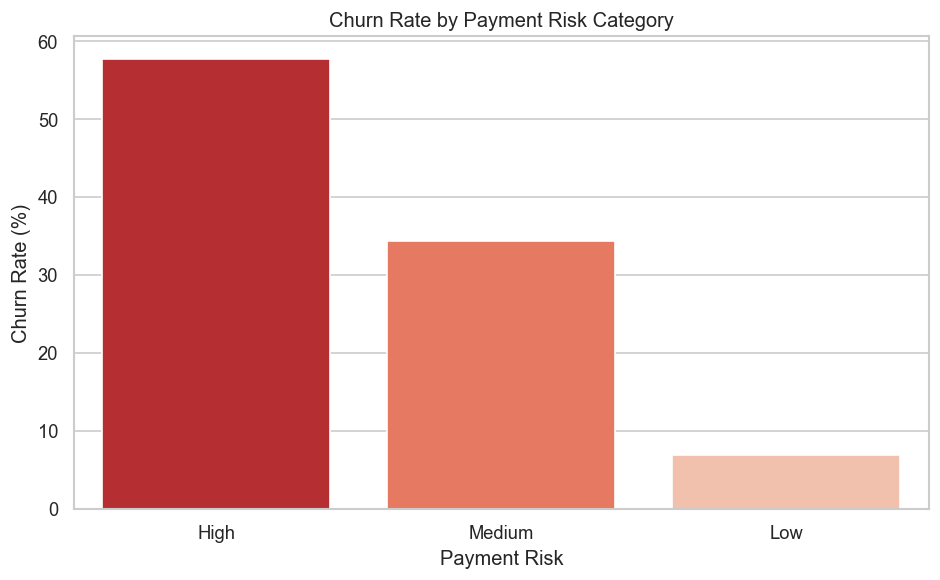

In [12]:
risk = df.groupby("Payment Risk", observed=True)["Churn_encoded"].agg(["count", "mean"])
risk["churn_rate_pct"] = (risk["mean"] * 100).round(1)
display(risk)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=risk.reset_index(), x="Payment Risk", y="churn_rate_pct",
            order=["High", "Medium", "Low"], ax=ax, palette="Reds_r")
ax.set_title("Churn Rate by Payment Risk Category")
ax.set_ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_payment_risk_churn.png")
plt.show()

## 11. EDA — Tenure vs monthly charges

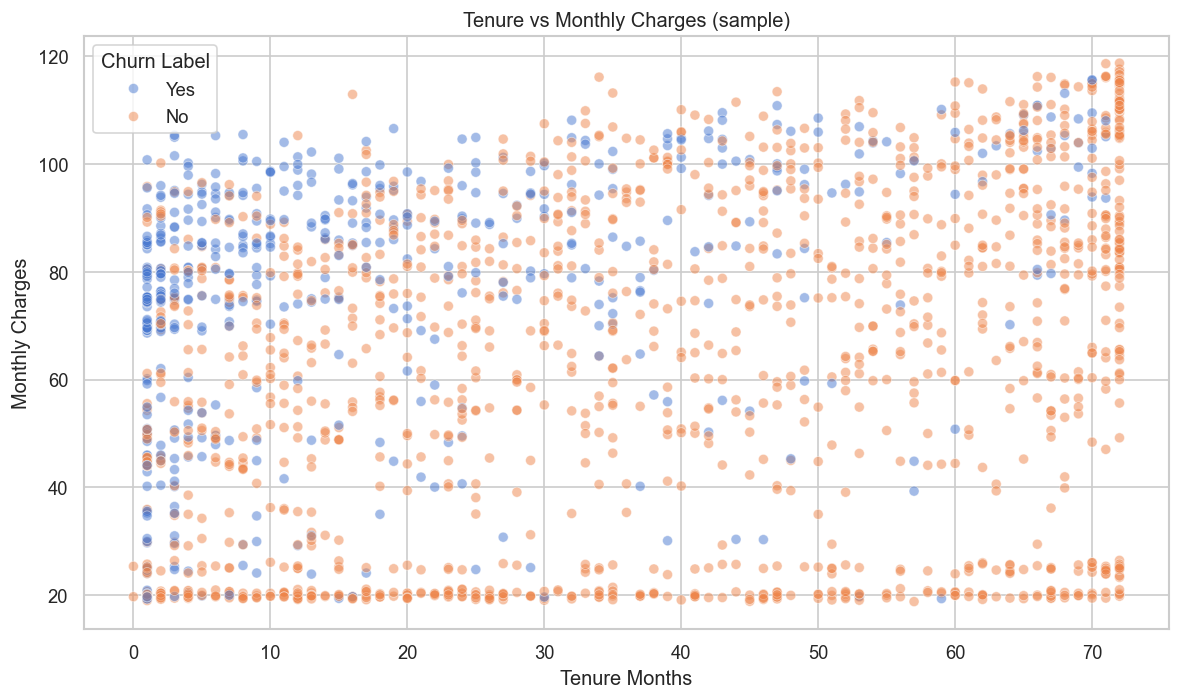

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df.sample(min(2000, len(df)), random_state=42),
                x="Tenure Months", y="Monthly Charges", hue="Churn Label", alpha=0.5, ax=ax)
ax.set_title("Tenure vs Monthly Charges (sample)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_tenure_vs_charges.png")
plt.show()

## 12. Save cleaned dataset

In [ ]:
df.to_csv(CLEANED_CSV, index=False)
print(f"Saved {len(df):,} rows to {CLEANED_CSV}")